# 1 — Exploratory Data Analysis (EDA)
Notebook ini membaca `data/raw/dataset.csv` lalu melakukan EDA dasar (ringkasan, missing values, distribusi, korelasi).

In [1]:
# Setup path + imports
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme()

ROOT = Path.cwd().resolve()
while not (ROOT / 'src').exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

DATASET_PATH = ROOT / 'data' / 'raw' / 'customer_purchase_data.csv'
DATASET_PATH

WindowsPath('C:/Users/bobok/modul2_datamining/data/raw/customer_purchase_data.csv')

In [2]:
# Load dataset
if not DATASET_PATH.exists():
    raise FileNotFoundError(f'Dataset tidak ditemukan: {DATASET_PATH}')

df = pd.read_csv(DATASET_PATH)
print('Shape:', df.shape)
df.head()

Shape: (25, 6)


,age,income,education_level,years_experience,monthly_spending,purchased
0,22,3200,SMA,1,500,0
1,25,4500,D3,2,650,0
2,28,5200,S1,4,700,0
3,30,6100,S1,5,850,1
4,33,7200,S1,7,920,1


In [3]:
# Info umum
display(df.info())
df.describe(include='all')

<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   age               25 non-null     int64
 1   income            25 non-null     int64
 2   education_level   25 non-null     str  
 3   years_experience  25 non-null     int64
 4   monthly_spending  25 non-null     int64
 5   purchased         25 non-null     int64
dtypes: int64(5), str(1)
memory usage: 1.4 KB


None

,age,income,education_level,years_experience,monthly_spending,purchased
count,25.000000,25.000000,25,25.000000,25.000000,25.000000
unique,NaN,NaN,4,NaN,NaN,NaN
top,NaN,NaN,S1,NaN,NaN,NaN
freq,NaN,NaN,12,NaN,NaN,NaN
mean,34.040000,7356.000000,NaN,7.720000,942.400000,0.680000
std,7.430119,2524.724407,NaN,4.632494,290.233814,0.476095
min,22.000000,3200.000000,NaN,1.000000,480.000000,0.000000
25%,28.000000,5200.000000,NaN,4.000000,700.000000,0.000000
50%,34.000000,7600.000000,NaN,7.000000,940.000000,1.000000
75%,40.000000,9500.000000,NaN,12.000000,1180.000000,1.000000


In [4]:
# Missing values & duplicates
missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0])
print('Duplicate rows:', df.duplicated().sum())

Series([], dtype: int64)

Duplicate rows: 0


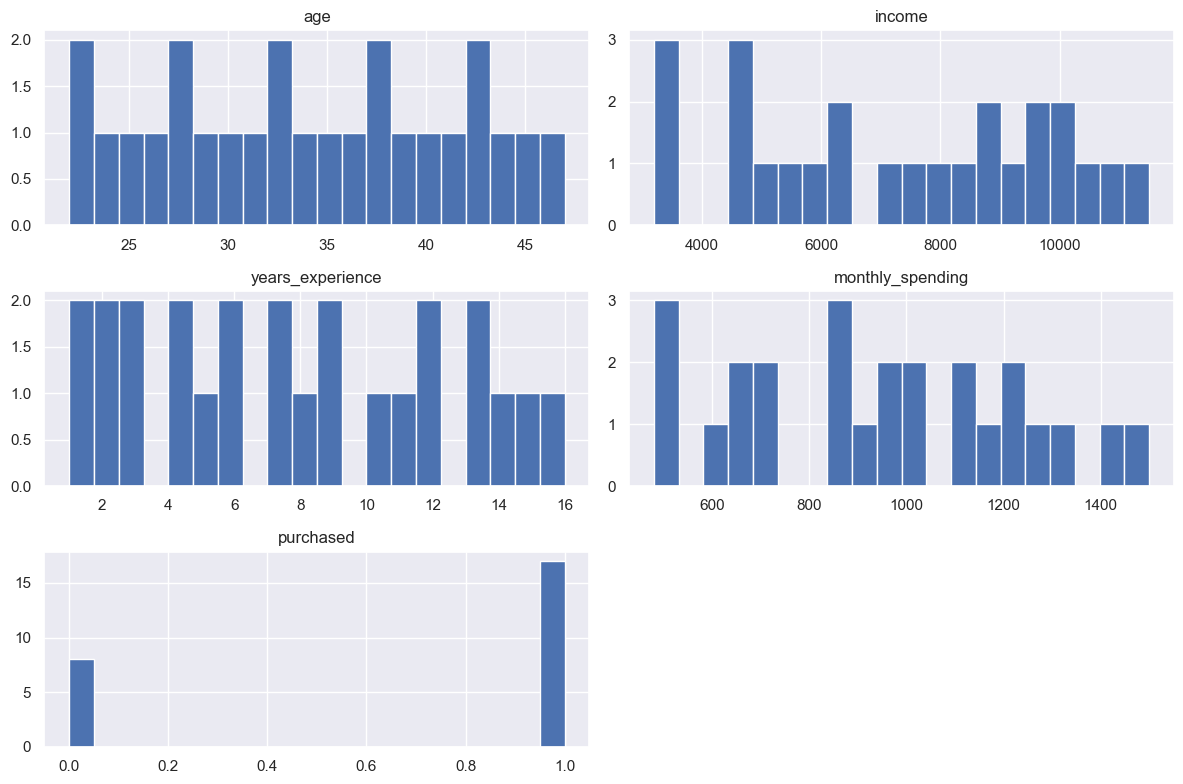

In [5]:
# Distribusi kolom numerik
num_cols = df.select_dtypes(include=['number']).columns.tolist()
df[num_cols].hist(bins=20, figsize=(12, 8))
plt.tight_layout()
plt.show()

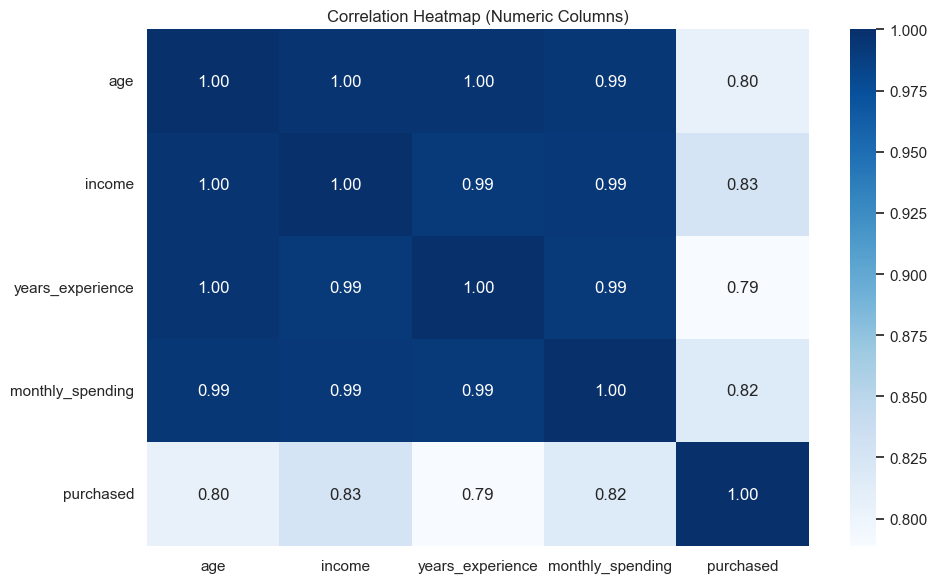

In [6]:
# Korelasi (numerik)
if len(num_cols) >= 2:
    corr = df[num_cols].corr(numeric_only=True)
    plt.figure(figsize=(10, 6))
    sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f')
    plt.title('Correlation Heatmap (Numeric Columns)')
    plt.tight_layout()
    plt.show()
else:
    print('Tidak cukup kolom numerik untuk korelasi.')